In [3]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

In [ ]:
csv_filename = "Mall_Customers.csv"

# Download raw CSV directly if not already locally present
if not os.path.exists(csv_filename):
    print("Downloading dataset...")
    url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
    urllib.request.urlretrieve(url, csv_filename)
    print("Download complete!")

Download complete!


In [5]:
df = pd.read_csv(csv_filename)

In [7]:
print("\n--- Dataset Head ---")
print(df.head())

print("\n--- Check Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe())


--- Dataset Head ---
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- Check Missing Values ---
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

--- Summary Statistics ---
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.00

In [8]:
# Standardize column naming for consistency
df.rename(columns={
    'Annual Income (k$)': 'Annual Income (Lakhs)',
    'Spending Score (1-100)': 'Spending Score'
}, inplace=True)

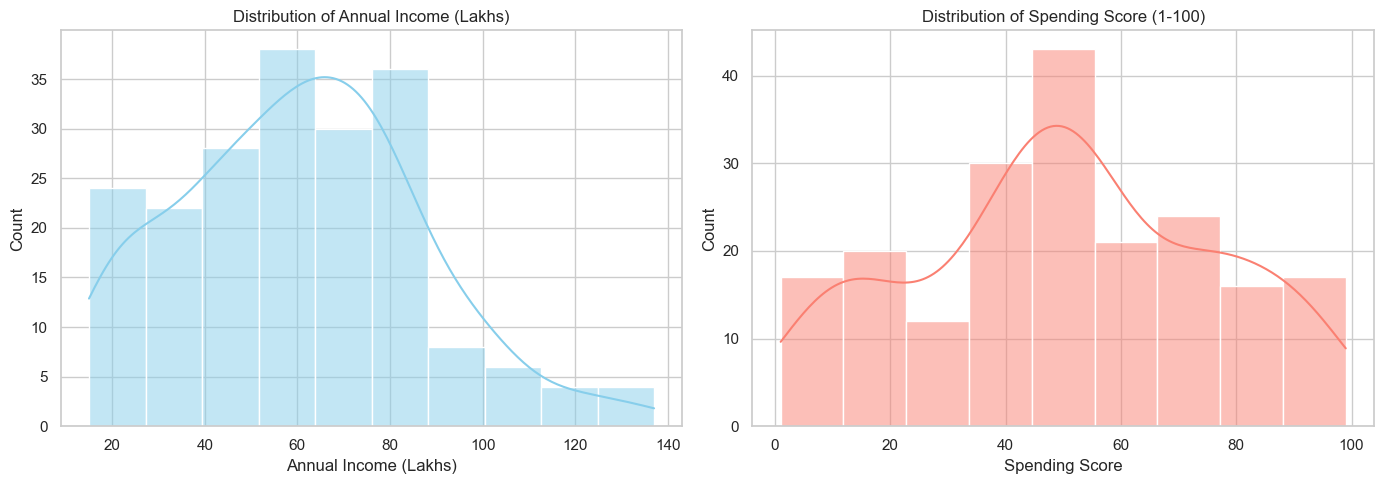

In [9]:
# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Annual Income (Lakhs)'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Annual Income (Lakhs)')

sns.histplot(df['Spending Score'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Spending Score (1-100)')

plt.tight_layout()
plt.show()

In [10]:
# Select appropriate features for clustering
X = df[['Annual Income (Lakhs)', 'Spending Score']].values

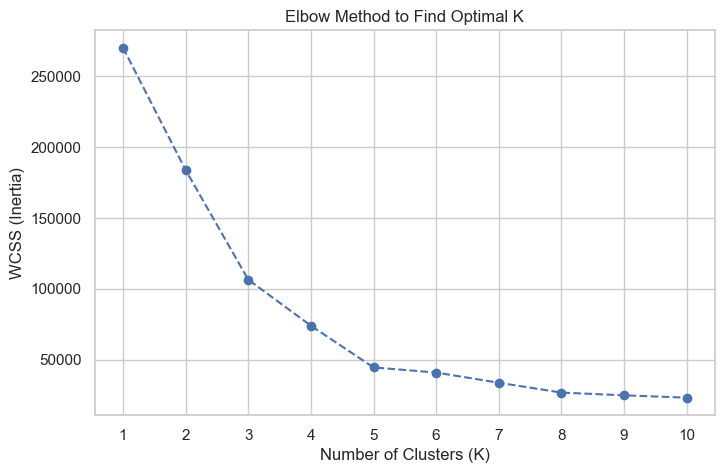

In [18]:
# Elbow Method for Optimal K
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.show()

In [12]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Customer_Segment'] = kmeans.fit_predict(X)

In [14]:
print("\n--- Data with Assigned Customer Segments ---")
print(df.head())


--- Data with Assigned Customer Segments ---
   CustomerID   Genre  Age  Annual Income (Lakhs)  Spending Score  \
0           1    Male   19                     15              39   
1           2    Male   21                     15              81   
2           3  Female   20                     16               6   
3           4  Female   23                     16              77   
4           5  Female   31                     17              40   

   Customer_Segment  
0                 4  
1                 2  
2                 4  
3                 2  
4                 4  


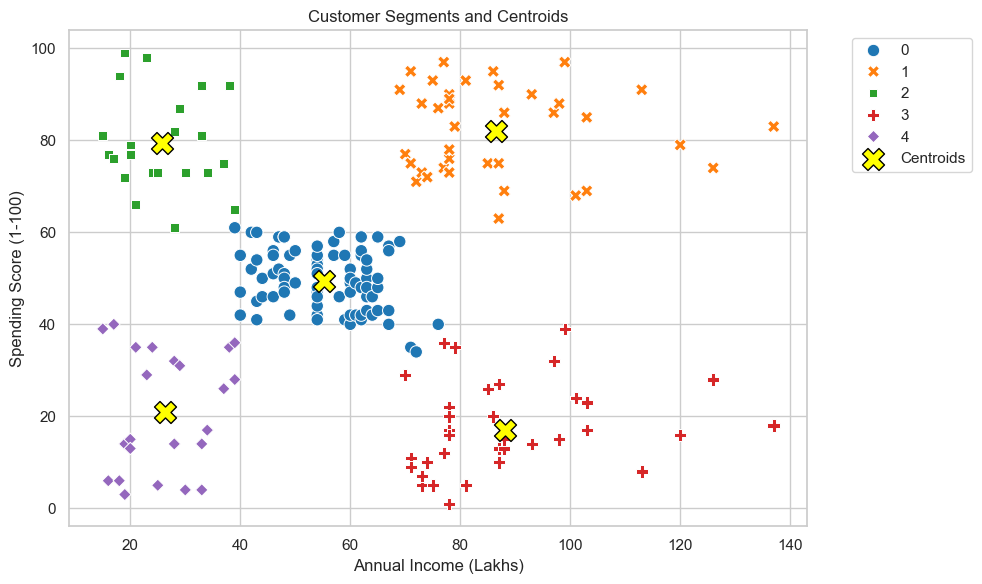

In [16]:
# Cluster Visualization
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X[:, 0], 
    y=X[:, 1], 
    hue=df['Customer_Segment'], 
    palette='tab10', 
    s=80,
    style=df['Customer_Segment']
)

# Plot Centroids
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    s=250, 
    c='yellow', 
    marker='X', 
    edgecolor='black', 
    label='Centroids'
)

plt.title('Customer Segments and Centroids')
plt.xlabel('Annual Income (Lakhs)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
# Business Perspectives & Analysis
cluster_summary = df.groupby('Customer_Segment').agg(
    Avg_Income=('Annual Income (Lakhs)', 'mean'),
    Avg_Spending=('Spending Score', 'mean'),
    Avg_Age=('Age', 'mean'),
    Customer_Count=('CustomerID', 'count')
).reset_index()

print("\n--- Cluster Analysis Metrics ---")
print(cluster_summary)


--- Cluster Analysis Metrics ---
   Customer_Segment  Avg_Income  Avg_Spending    Avg_Age  Customer_Count
0                 0   55.296296     49.518519  42.716049              81
1                 1   86.538462     82.128205  32.692308              39
2                 2   25.727273     79.363636  25.272727              22
3                 3   88.200000     17.114286  41.114286              35
4                 4   26.304348     20.913043  45.217391              23
